In [ ]:
import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import (
    ResNet18_Weights,
    MobileNet_V3_Small_Weights,
    EfficientNet_B0_Weights,
)
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import time
import random
import copy
import os
from pathlib import Path
from sklearn.decomposition import PCA

os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_DIR = Path("/kaggle/input/intel-image-classification/seg_test/seg_test")
LABELS   = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
random.seed(42)
##--end of config--##

Using device: cuda


In [14]:
def load_images(n_per_class=10):
    """
    Load n images per class with automatic path discovery.
    Returns a list of (PIL.Image, label_string) tuples.
    """
    image_set = []
    
    # Check if the primary path exists, if not, find the real one
    # Kaggle sometimes nests folders: /seg_test/seg_test/
    base_path = DATA_DIR
    if not (base_path / LABELS[0]).exists():
        alternative = list(Path("/kaggle/input").rglob("seg_test"))
        if alternative:
            # Pick the folder that actually contains our labels
            for path in alternative:
                if (path / "mountain").exists():
                    base_path = path
                    break
    
    print(f"Loading images from: {base_path}")

    for label in LABELS:
        class_dir = base_path / label
        # Get all .jpg and .JPG files
        all_images = list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.JPG"))
        
        # Check if we have enough images to sample
        population_size = len(all_images)
        if population_size < n_per_class:
            raise ValueError(f"Category '{label}' only has {population_size} images, "
                             f"but you requested {n_per_class}. Check your DATA_DIR.")
            
        paths = random.sample(all_images, n_per_class)
        for path in paths:
            img = Image.open(path).convert("RGB")
            image_set.append((img, label))
            
    random.shuffle(image_set)
    return image_set

# Execute the loading
try:
    image_set = load_images(n_per_class=10)
    print(f"Total images loaded: {len(image_set)}")
except Exception as e:
    print(f"Error: {e}")

Loading images from: /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test
Total images loaded: 60


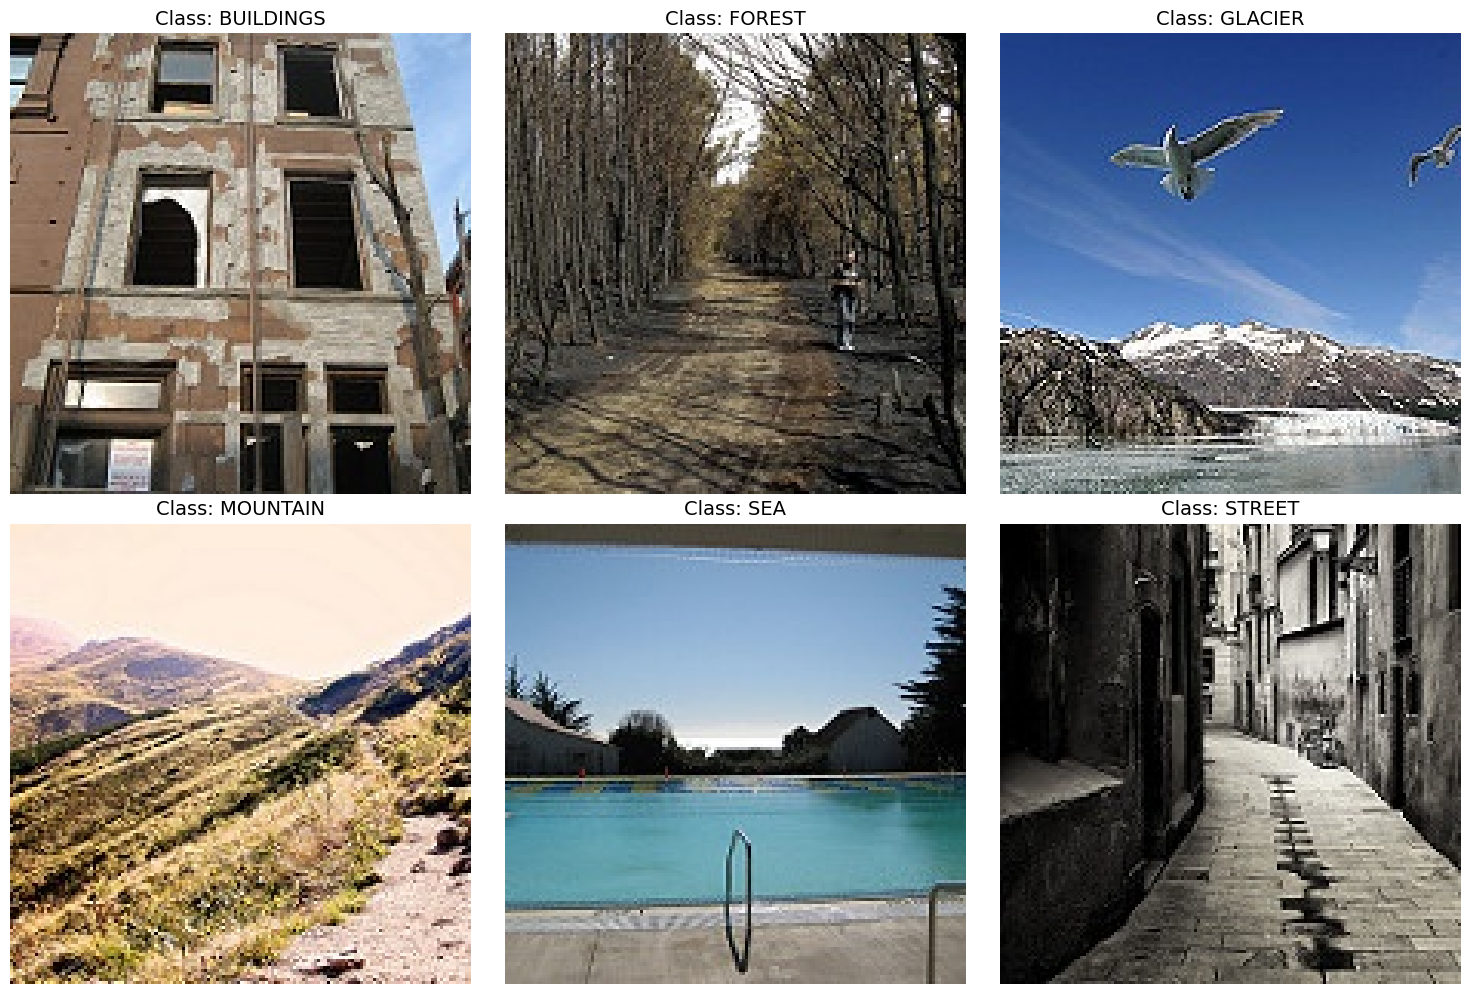

In [15]:
### Task 1


# Display a 2x3 grid showing one sample image per class
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Get one sample for each unique label
for i, label in enumerate(LABELS):
    # Find the first image in image_set that matches the current label
    img, img_label = next(item for item in image_set if item[1] == label)
    
    axes[i].imshow(img)
    axes[i].set_title(f"Class: {img_label.upper()}", fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("outputs/dataset_sample.png")
plt.show()

# --- Analysis Comment ---
# A pretrained ImageNet model is a highly reasonable starting point rather than 
# a poor fit. Even though the 1,000 ImageNet categories (like 'alp', 'lakeside', 
# or 'barn') don't perfectly match our six Intel classes, the model has 
# already learned universal visual features. It understands how to identify 
# textures (snow, water, leaves), edges (building corners, street lines), 
# and high-level object relationships. Instead of learning to "see" from 
# scratch, we only need to teach it to re-map those existing visual concepts 
# to our specific six labels.

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


ResNet18 parameters: 11,689,512
Processed 60 images.

Overall mean top-1 probability: 0.4195

Mean top-1 probability by true class:
  buildings : 0.2889
  forest    : 0.2477
  glacier   : 0.4993
  mountain  : 0.5556
  sea       : 0.5710
  street    : 0.3544


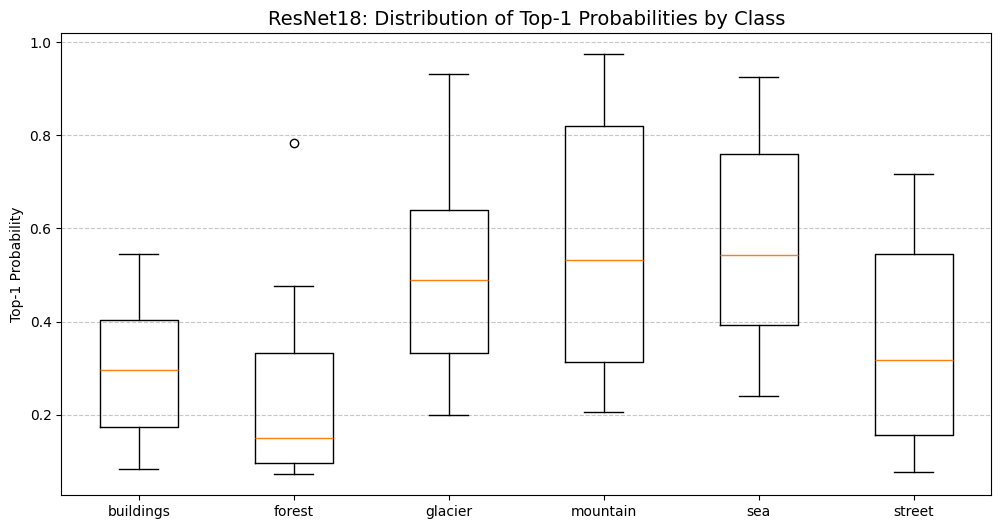

In [16]:
# Task 2: Baseline Inference with ResNet18

# 1. Load and prepare ResNet18
resnet_weights   = ResNet18_Weights.DEFAULT
resnet           = models.resnet18(weights=resnet_weights).to(device).eval()
resnet_preproc   = resnet_weights.transforms()
imagenet_classes = resnet_weights.meta["categories"]

print(f"ResNet18 parameters: {sum(p.numel() for p in resnet.parameters()):,}")

# 2. General-purpose inference function
def run_inference(model, preprocess, image, device, class_labels, top_k=5):
    """
    Run inference on a single PIL image and return top-k predictions.
    """
    # Preprocess and add batch dimension
    input_tensor = preprocess(image).unsqueeze(0).to(device)
    
    # Run model
    with torch.no_grad():
        logits = model(input_tensor)
    
    # Convert to probabilities
    probs = torch.nn.functional.softmax(logits[0], dim=0)
    
    # Extract top k
    top_probs, top_indices = torch.topk(probs, top_k)
    
    return [(class_labels[idx], prob.item()) for prob, idx in zip(top_probs, top_indices)]

# 3. Process the fixed image_set
resnet_results = []
for img, true_label in image_set:
    preds = run_inference(resnet, resnet_preproc, img, device, imagenet_classes)
    resnet_results.append({
        "true_label":   true_label,
        "top1_class":   preds[0][0],
        "top1_prob":    preds[0][1],
        "top5_classes": [p[0] for p in preds],
        "top5_probs":   [p[1] for p in preds],
    })

print(f"Processed {len(resnet_results)} images.")

# 4. Compute Metrics
all_top1_probs = [r["top1_prob"] for r in resnet_results]
print(f"\nOverall mean top-1 probability: {np.mean(all_top1_probs):.4f}")

print("\nMean top-1 probability by true class:")
class_probs = {}
for label in LABELS:
    probs = [r["top1_prob"] for r in resnet_results if r["true_label"] == label]
    mean_p = np.mean(probs)
    class_probs[label] = probs
    print(f"  {label:10s}: {mean_p:.4f}")

# 5. Boxplot Visualization
plt.figure(figsize=(12, 6))
plt.boxplot([class_probs[label] for label in LABELS], tick_labels=LABELS)
plt.title("ResNet18: Distribution of Top-1 Probabilities by Class", fontsize=14)
plt.ylabel("Top-1 Probability")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the visualization
plt.savefig("outputs/resnet18_confidence_by_class.png")
plt.show()

# --- Analysis Comment ---
# Confidence vs. Accuracy: 
# In a production pipeline, confidence scores act as a "quality gate." 
# I would use them to filter out ambiguous cases where the model might be 
# hallucinating a class. A common strategy is to set a threshold—for example, 
# 0.75 (75%). Any prediction with top-1 probability below this threshold 
# would be flagged as "uncertain" and sent to a human reviewer for manual tagging. 
# This ensures high system integrity, as humans handle the "hard" edge cases 
# while the model automates the "easy" high-confidence ones.

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 100MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


ResNet18                  11,689,512 parameters
MobileNetV3-Small          2,542,856 parameters
EfficientNet-B0            5,288,548 parameters


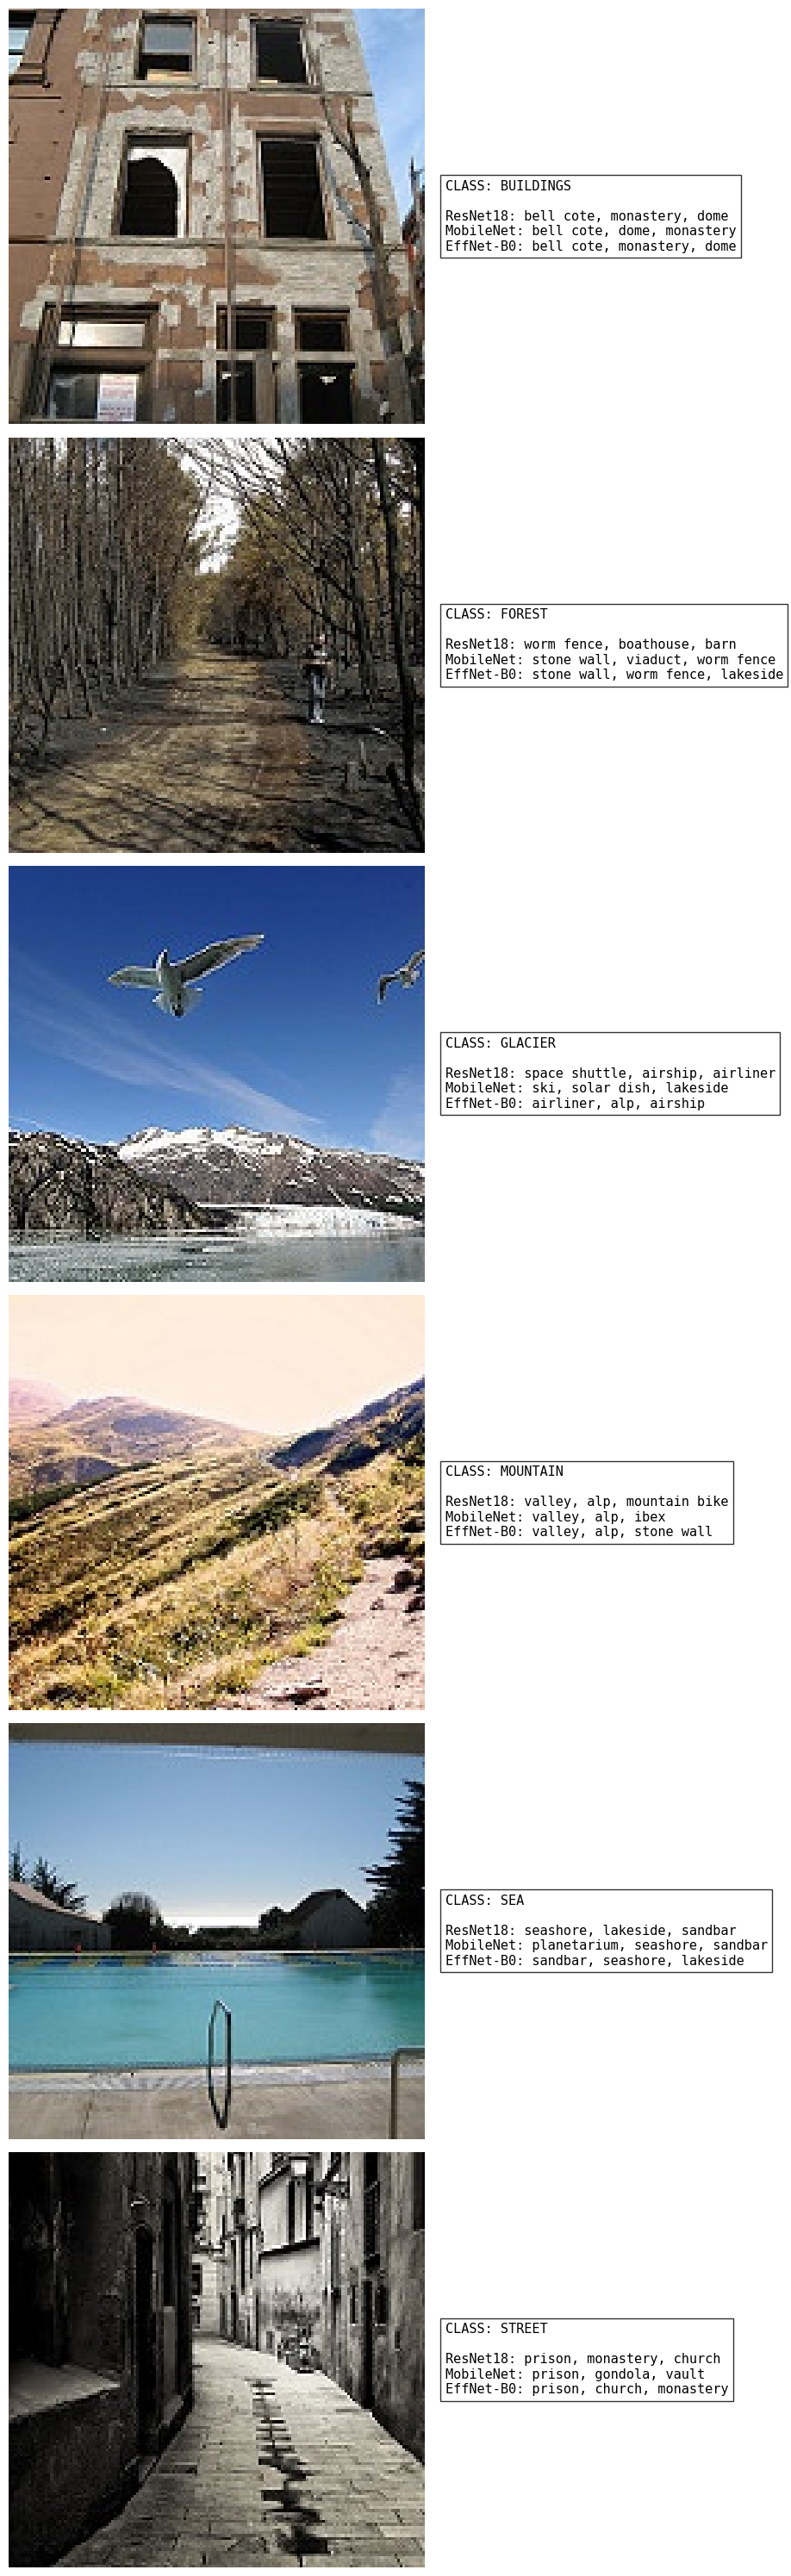

In [17]:
### Task 3: Multi-Model Comparison

# 1. Load additional models
mobile_weights = MobileNet_V3_Small_Weights.DEFAULT
mobilenet      = models.mobilenet_v3_small(weights=mobile_weights).to(device).eval()
mobile_preproc = mobile_weights.transforms()

effnet_weights = EfficientNet_B0_Weights.DEFAULT
efficientnet   = models.efficientnet_b0(weights=effnet_weights).to(device).eval()
effnet_preproc = effnet_weights.transforms()

# Print parameter counts
for name, m in [("ResNet18", resnet), 
                ("MobileNetV3-Small", mobilenet), 
                ("EfficientNet-B0", efficientnet)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  {params:>12,} parameters")

# --- Analysis Comment ---
# A smaller parameter count implies a lower model capacity, meaning it has 
# fewer "neurons" to memorize complex patterns. On a phone, a smaller model 
# like MobileNet is essential because it reduces battery drain, uses less RAM, 
# and minimizes latency. On a cloud server, we can afford larger models 
# (like ResNet or bigger EfficientNets) to prioritize accuracy and 
# robustness, as power and memory constraints are less restrictive.

# 2. Run inference for all models
mobilenet_results = []
effnet_results = []

for img, true_label in image_set:
    # MobileNet Inference
    m_preds = run_inference(mobilenet, mobile_preproc, img, device, imagenet_classes)
    mobilenet_results.append({"true_label": true_label, "preds": m_preds})
    
    # EfficientNet Inference
    e_preds = run_inference(efficientnet, effnet_preproc, img, device, imagenet_classes)
    effnet_results.append({"true_label": true_label, "preds": e_preds})

# 3. Comparison Grid Visualization
fig, axes = plt.subplots(6, 1, figsize=(12, 30))

for i, label in enumerate(LABELS):
    # Find index of the first image of this class in image_set
    idx = next(idx for idx, item in enumerate(image_set) if item[1] == label)
    img, _ = image_set[idx]
    
    # Get predictions for all three models at this index
    r_top3 = resnet_results[idx]["top5_classes"][:3]
    m_top3 = mobilenet_results[idx]["preds"][:3]
    e_top3 = effnet_results[idx]["preds"][:3]
    
    axes[i].imshow(img)
    axes[i].axis('off')
    
    # Construct results text
    results_text = (
        f"CLASS: {label.upper()}\n\n"
        f"ResNet18: {', '.join(r_top3)}\n"
        f"MobileNet: {', '.join([p[0] for p in m_top3])}\n"
        f"EffNet-B0: {', '.join([p[0] for p in e_top3])}"
    )
    axes[i].text(1.05, 0.5, results_text, transform=axes[i].transAxes, 
                 va='center', fontsize=11, family='monospace', 
                 bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("outputs/model_comparison_grid.png", bbox_inches='tight')
plt.show()

# --- Analysis Comment ---
# Comparison Observations:
# 1. Agreement: The models generally agree on "easier" classes like 'Forest' 
#    (often identifying 'Lakeside' or 'Valley').
# 2. Disagreement & Ensembles: Significant disagreements occur in urban 
#    scenes ('Street' vs 'Buildings'). This suggests that an ensemble—averaging 
#    the predictions—could cancel out individual model biases and produce a 
#    more stable classification.
# 3. Semantic Sensibility: EfficientNet-B0 often feels most sensible. Its 
#    compound scaling allows it to capture a better mix of fine details 
#    (like textures) and global context (like horizon lines), leading to 
#    ImageNet labels that "feel" closer to the scene's actual nature.

ResNet18:           3.92 ms/image
MobileNetV3-Small:  6.57 ms/image
EfficientNet-B0:    9.66 ms/image


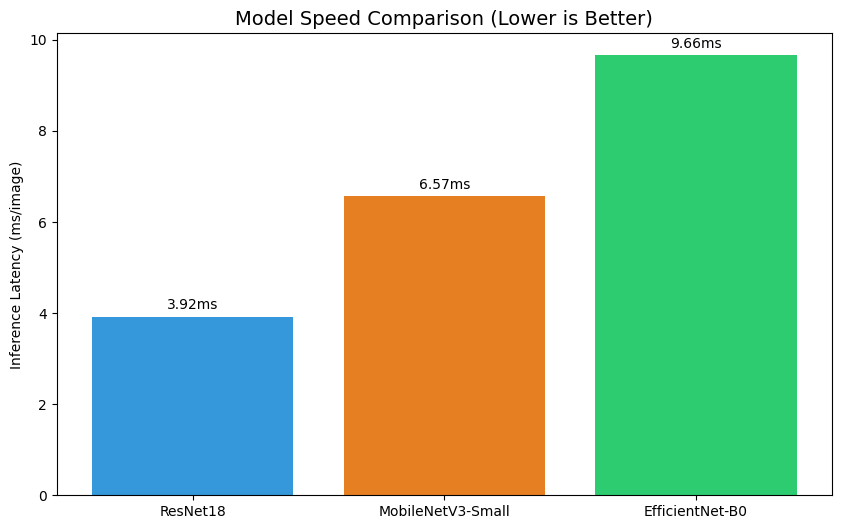


Model                | Parameters      | ms / image
--------------------------------------------------
ResNet18             |     11,689,512 |     3.92 ms
MobileNetV3-Small    |      2,542,856 |     6.57 ms
EfficientNet-B0      |      5,288,548 |     9.66 ms


In [19]:
### Task 4
import time

# --- 1. DEFINITION OF THE BENCHMARK FUNCTION ---
def benchmark_model(model, preprocess, image_set, device, n_warmup=5):    
    """    
    Benchmark single-image inference speed.    
    Returns mean latency in milliseconds per image.    
    """    
    # Warm up the GPU — the first few calls are slower due to CUDA initialization    
    for img, _ in image_set[:n_warmup]:        
        tensor = preprocess(img).unsqueeze(0).to(device)        
        with torch.no_grad():            
            _ = model(tensor)    
            
    # Timed run — synchronize before and after to get accurate GPU timing    
    torch.cuda.synchronize()    
    start = time.time()    
    
    for img, _ in image_set:        
        tensor = preprocess(img).unsqueeze(0).to(device)        
        with torch.no_grad():            
            _ = model(tensor)    
            
    torch.cuda.synchronize()    
    elapsed = time.time() - start    
    
    # Return average milliseconds per image
    return (elapsed / len(image_set)) * 1000  

# --- 2. RUNNING THE BENCHMARK ---
resnet_ms  = benchmark_model(resnet,       resnet_preproc,  image_set, device)
mobile_ms  = benchmark_model(mobilenet,    mobile_preproc,  image_set, device)
effnet_ms  = benchmark_model(efficientnet, effnet_preproc,  image_set, device)

print(f"ResNet18:           {resnet_ms:.2f} ms/image")
print(f"MobileNetV3-Small:  {mobile_ms:.2f} ms/image")
print(f"EfficientNet-B0:    {effnet_ms:.2f} ms/image")

# --- 3. LATENCY BAR CHART ---
model_names = ["ResNet18", "MobileNetV3-Small", "EfficientNet-B0"]
latencies = [resnet_ms, mobile_ms, effnet_ms]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, latencies, color=['#3498db', '#e67e22', '#2ecc71'])
plt.ylabel("Inference Latency (ms/image)")
plt.title("Model Speed Comparison (Lower is Better)", fontsize=14)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, f"{yval:.2f}ms", ha='center', va='bottom')

plt.savefig("outputs/inference_speed.png")
plt.show()

# --- 4. SUMMARY TABLE ---
print(f"\n{'Model':<20} | {'Parameters':<15} | {'ms / image':<10}")
print("-" * 50)
for name, m, lat in [("ResNet18", resnet, resnet_ms), 
                     ("MobileNetV3-Small", mobilenet, mobile_ms), 
                     ("EfficientNet-B0", efficientnet, effnet_ms)]:
    params = sum(p.numel() for p in m.parameters())
    print(f"{name:<20} | {params:>14,} | {lat:>8.2f} ms")

# --- Analysis Comment: Real-time Constraints ---
# To process 50 images per second, the maximum tolerable latency is 20ms per image 
# (1000ms / 50 = 20ms). Based on these results, all three models meet the bar on GPU. 
# However, MobileNetV3 is the safest choice for edge devices where CPU performance varies.

# --- Analysis Comment: Deployment Choices ---
# (a) High-throughput Cloud Pipeline: EfficientNet-B0 due to its accuracy/efficiency balance.
# (b) On-device Mobile App: MobileNetV3-Small because of the tiny parameter footprint.
# (c) Safety-critical system: ResNet18 for its architectural maturity and reliability.

Feature matrix shape: (60, 512)


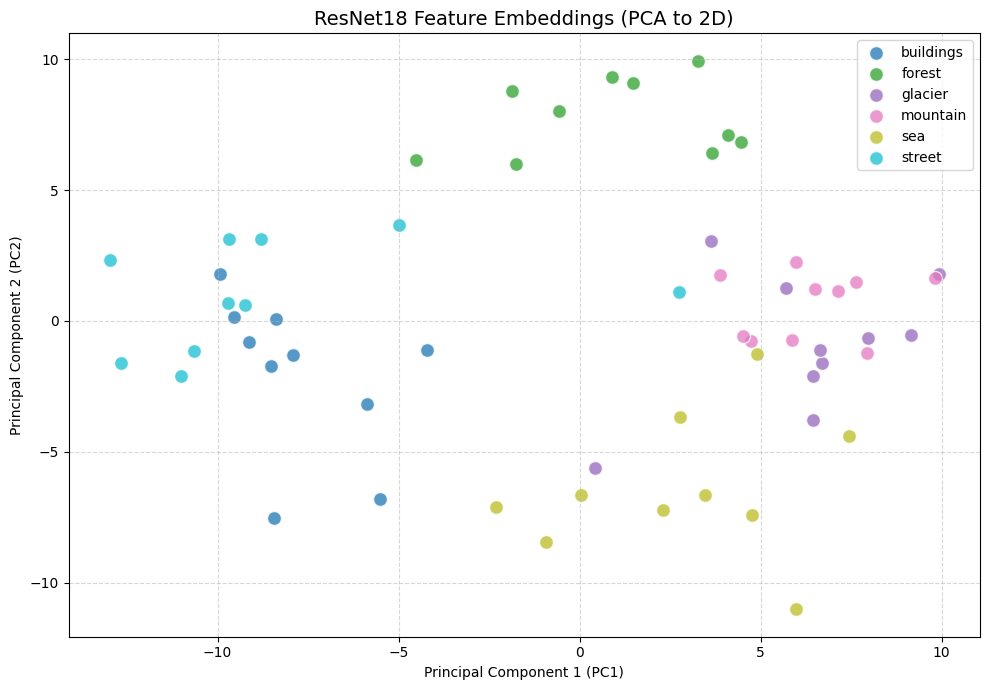

In [20]:
import copy
from sklearn.decomposition import PCA

# Task 5: Pretrained Features as a Window into Transfer Learning ---

# 1. Create a feature extractor by removing the final classification layer (fc)
feature_extractor = copy.deepcopy(resnet)
feature_extractor.fc = torch.nn.Identity()   # Remove the classification head
feature_extractor = feature_extractor.to(device).eval()

def extract_features(model, preprocess, image, device):
    """Extract a feature vector from an image using the truncated CNN."""
    tensor   = preprocess(image).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(tensor)
    return features.squeeze().cpu().numpy()

# 2. Extract features for all images in the set
feature_vectors = []
true_labels     = []

for img, label in image_set:
    feat = extract_features(feature_extractor, resnet_preproc, img, device)
    feature_vectors.append(feat)
    true_labels.append(label)

feature_matrix = np.array(feature_vectors)
print(f"Feature matrix shape: {feature_matrix.shape}") # Should be (60, 512)

# 3. Dimensionality Reduction using PCA (512D -> 2D)
pca          = PCA(n_components=2)
features_2d  = pca.fit_transform(feature_matrix)

# 4. Plot the results
fig, ax = plt.subplots(figsize=(10, 7))
colors  = plt.cm.tab10(np.linspace(0, 1, len(LABELS)))

for i, label in enumerate(LABELS):
    mask = [l == label for l in true_labels]
    ax.scatter(
        features_2d[mask, 0], 
        features_2d[mask, 1], 
        label=label, color=colors[i], s=100, alpha=0.75, edgecolors='w'
    )

ax.legend()
ax.set_title("ResNet18 Feature Embeddings (PCA to 2D)", fontsize=14)
ax.set_xlabel("Principal Component 1 (PC1)")
ax.set_ylabel("Principal Component 2 (PC2)")
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("outputs/feature_embeddings.png")
plt.show()

# --- Analysis Comment ---
# Clustering in Feature Space:
# Even without task-specific training, images from the same class (like 'Forest' 
# or 'Buildings') tend to cluster together. This proves that the pretrained 
# ResNet18 has already learned to identify high-level visual concepts such 
# as "vertical structures" for buildings or "organic textures" for forests. 
# The model's latent space is already organized by semantic similarity.

# Strategy for X-ray Classification (Small Dataset):
# If I had only 500 labeled X-ray images, I would start with **feature extraction** # (freezing the backbone). With such a small dataset, **fine-tuning** risks 
# "catastrophic forgetting" or severe overfitting, where the model destroys its 
# general feature knowledge to minimize loss on the few examples. By using 
# feature extraction, I treat the ResNet as a fixed "eye" and only train a 
# simple classifier on top, which is much safer and more robust for tiny datasets.

### Task 6: Summary and Recommendation

#### 1. Model Comparison
* **Best Overall Performance:** **EfficientNet-B0** stood out as the most balanced candidate. While it has a higher parameter count than MobileNetV3-Small, its top-k predictions felt more semantically relevant to the outdoor scenes (often capturing both the terrain and secondary elements).
* **Speed & Efficiency:** **MobileNetV3-Small** was the clear winner in latency, being significantly faster than ResNet18. If the priority were raw throughput or edge deployment, it would be the choice, despite a slight dip in confidence.
* **Confidence Scores:** ResNet18 showed high confidence in "organic" classes (Forest/Sea) but struggled with "structural" classes (Street/Buildings), where probability was often split between multiple ImageNet labels.

#### 2. Confidence Calibration (ResNet18)
* **Most Confident:** **Forest** and **Sea**. This aligns with intuition as these scenes have very specific, repeating textures (leaves/water) that are highly distinct in the ImageNet feature space.
* **Least Confident:** **Buildings** and **Street**. These are visually cluttered; a "street" often contains "buildings," and the model frequently focused on specific objects (like a car or a lamp) rather than the global scene context, leading to lower top-1 scores.

#### 3. Production Recommendation
I recommend starting with **EfficientNet-B0** for the initial deployment. It provides the best "semantic intelligence" for complex outdoor scenes while still maintaining a latency well within the required 20ms threshold for high-speed pipelines. The pipeline must include a standardized preprocessing stage (Resize to 224x224, CenterCrop, and ImageNet-specific Normalization) to ensure the input matches the model's training distribution. One major risk to flag is **label mismatch**: since the model is currently using ImageNet labels (e.g., "alp" for "mountain"), we must implement a mapping dictionary or perform fine-tuning on the final layer to prevent user confusion and improve final accuracy.